<a href="https://colab.research.google.com/github/swathireddy178/Ad-Generator/blob/main/Instructor_Effectiveness_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Instructor Effectiveness Modeling (EdTech Context)

This project analyzes instructor effectiveness using learner outcome,
engagement, and feedback metrics from an EdTech platform.

The objective is to:
• Define instructor effectiveness
• Aggregate batch-level data to instructor-level
• Train a machine learning model to predict effectiveness tiers
• Interpret model results and discuss limitations

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

In [2]:
import pandas as pd
import numpy as np

np.random.seed(42)

n_batches = 500

data = {
    "batch_id": range(1, n_batches+1),
    "instructor_id": np.random.randint(1, 50, n_batches),
    "course_id": np.random.randint(100, 110, n_batches),

    "completion_rate": np.random.uniform(0.5, 1.0, n_batches),
    "dropout_rate": np.random.uniform(0.0, 0.4, n_batches),
    "avg_score_improvement": np.random.uniform(5, 30, n_batches),
    "avg_quiz_score": np.random.uniform(60, 95, n_batches),

    "avg_watch_time": np.random.uniform(0.5, 1.0, n_batches),
    "assignment_submission_rate": np.random.uniform(0.4, 1.0, n_batches),
    "forum_activity_rate": np.random.uniform(0.1, 0.8, n_batches),

    "avg_feedback_score": np.random.uniform(3.0, 5.0, n_batches),
    "feedback_response_rate": np.random.uniform(0.3, 1.0, n_batches)
}

df = pd.DataFrame(data)

df.head()

,batch_id,instructor_id,course_id,completion_rate,dropout_rate,avg_score_improvement,avg_quiz_score,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate
0,1,39,104,0.953933,0.347249,23.107937,90.704162,0.995104,0.546238,0.232575,4.059428,0.462289
1,2,29,106,0.658098,0.285970,24.802341,71.564280,0.619579,0.560560,0.103519,4.464777,0.793894
2,3,15,109,0.794153,0.225100,15.119961,71.914205,0.765369,0.601404,0.142067,4.848215,0.515392
3,4,43,109,0.841491,0.188613,21.351895,94.615993,0.825479,0.849634,0.733336,4.950360,0.469522
4,5,8,105,0.725974,0.217293,13.855906,81.916166,0.822296,0.743147,0.553262,4.666409,0.351103


In [3]:
df.to_csv("instructor_data.csv", index=False)

Since no dataset was provided, a synthetic dataset was generated
based on the column definitions in the assignment description.

The dataset simulates course batches taught by different instructors,
including learner outcomes, engagement metrics, and feedback scores.

In [5]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   batch_id                    500 non-null    int64  
 1   instructor_id               500 non-null    int64  
 2   course_id                   500 non-null    int64  
 3   completion_rate             500 non-null    float64
 4   dropout_rate                500 non-null    float64
 5   avg_score_improvement       500 non-null    float64
 6   avg_quiz_score              500 non-null    float64
 7   avg_watch_time              500 non-null    float64
 8   assignment_submission_rate  500 non-null    float64
 9   forum_activity_rate         500 non-null    float64
 10  avg_feedback_score          500 non-null    float64
 11  feedback_response_rate      500 non-null    float64
dtypes: float64(9), int64(3)
memory usage: 47.0 KB


,batch_id,instructor_id,course_id,completion_rate,dropout_rate,avg_score_improvement,avg_quiz_score,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,250.500000,25.678000,104.426000,0.757011,0.197760,17.264623,77.758201,0.756555,0.716299,0.437312,3.954407,0.649115
std,144.481833,14.127898,2.934236,0.145022,0.109369,7.384708,10.120106,0.142428,0.168350,0.205424,0.582690,0.195192
min,1.000000,1.000000,100.000000,0.500119,0.000133,5.004710,60.073635,0.500221,0.401885,0.100942,3.000373,0.302686
25%,125.750000,14.000000,102.000000,0.634529,0.101520,10.637892,69.023122,0.637268,0.582357,0.257704,3.441363,0.483080
50%,250.500000,26.000000,104.000000,0.761888,0.204468,17.187397,78.524969,0.758304,0.727681,0.432719,3.928710,0.650423
75%,375.250000,37.000000,107.000000,0.885434,0.283108,23.733729,86.281284,0.885566,0.854996,0.629632,4.460382,0.817500
max,500.000000,49.000000,109.000000,0.999677,0.398192,29.926954,94.989983,0.999772,0.997839,0.798336,4.991276,0.998263


In [6]:
df.isnull().sum()

,0
batch_id,0
instructor_id,0
course_id,0
completion_rate,0
dropout_rate,0
avg_score_improvement,0
avg_quiz_score,0
avg_watch_time,0
assignment_submission_rate,0
forum_activity_rate,0


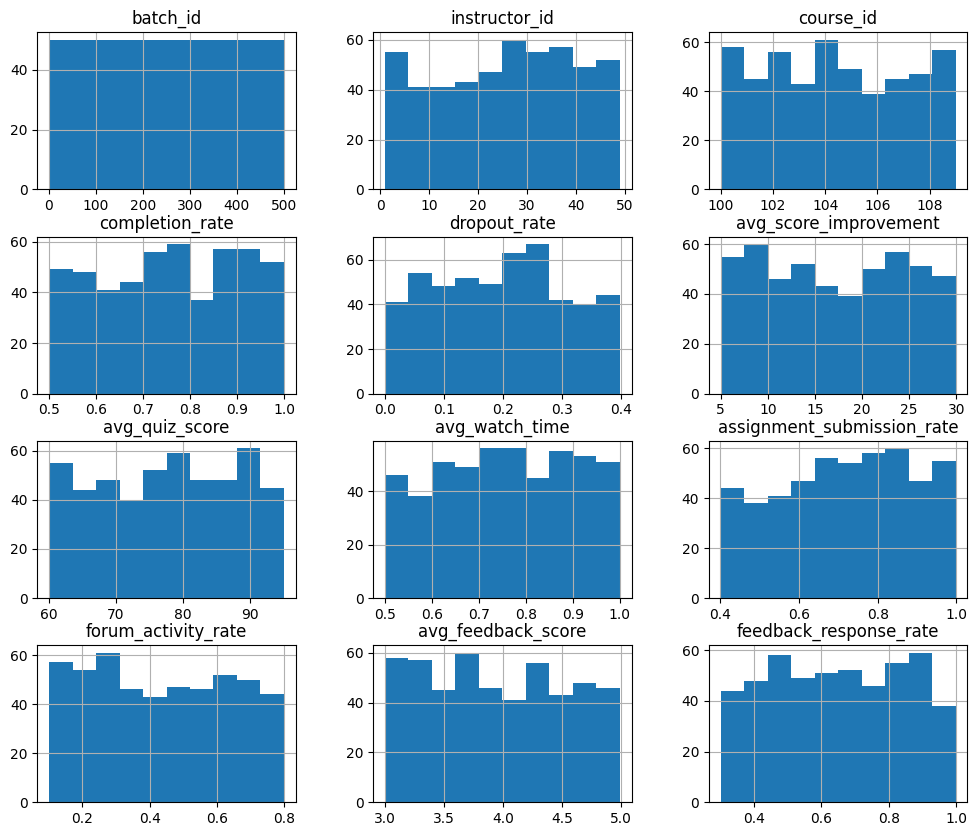

In [7]:
df.hist(figsize=(12,10))
plt.show()

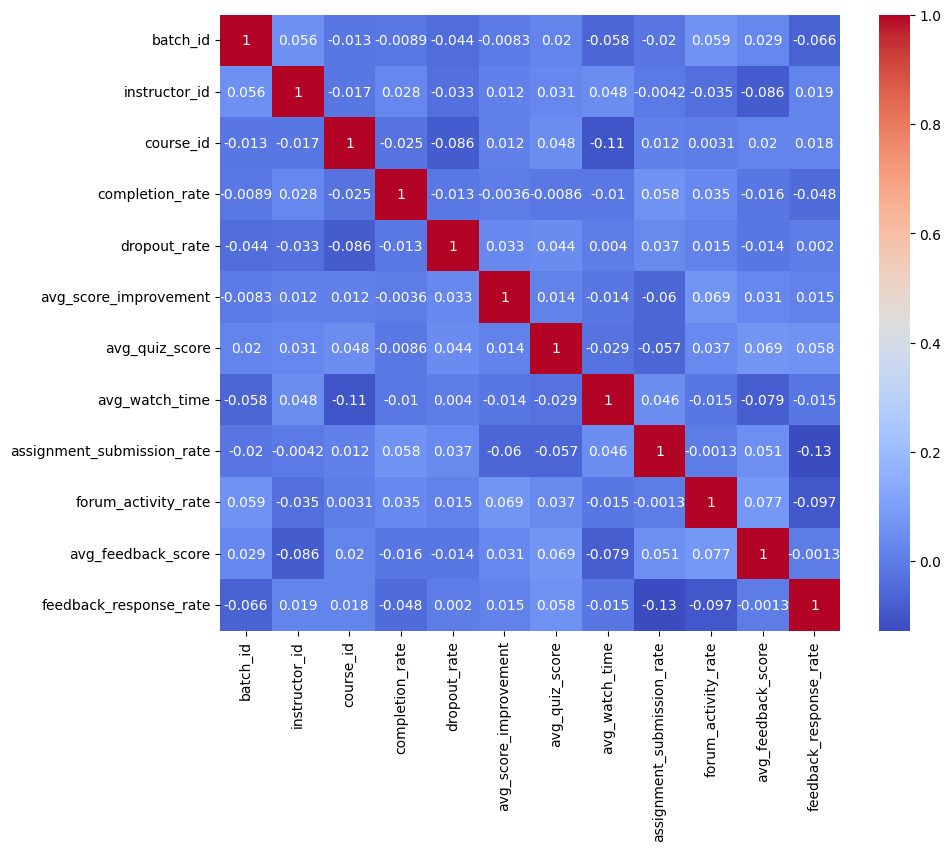

In [8]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.show()

The dataset contains metrics related to learner outcomes,
engagement, and feedback.

From the visualizations:
- Completion rate and quiz score show positive correlation.
- Dropout rate negatively correlates with engagement metrics.
- Feedback score appears moderately correlated with course success.

In [9]:
df["effectiveness_score"] = (
    0.3 * df["completion_rate"] +
    0.2 * df["avg_score_improvement"] +
    0.15 * df["avg_quiz_score"] +
    0.15 * df["avg_watch_time"] +
    0.1 * df["assignment_submission_rate"] +
    0.1 * df["avg_feedback_score"] -
    0.2 * df["dropout_rate"]
)

Instructor effectiveness is defined as a weighted combination
of learner outcomes, engagement metrics, and feedback.

Completion rate and score improvement receive higher weights
because they represent learning success.

Dropout rate negatively impacts effectiveness.

In [13]:
df["effectiveness_tier"] = pd.qcut(
    df["effectiveness_score"],
    q=3,
    labels=["Low","Medium","High"]
)

df.head()

,batch_id,instructor_id,course_id,completion_rate,dropout_rate,avg_score_improvement,avg_quiz_score,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate,effectiveness_score,effectiveness_tier
0,1,39,104,0.953933,0.347249,23.107937,90.704162,0.995104,0.546238,0.232575,4.059428,0.462289,19.053774,High
1,2,29,106,0.658098,0.285970,24.802341,71.564280,0.619579,0.560560,0.103519,4.464777,0.793894,16.430816,Medium
2,3,15,109,0.794153,0.225100,15.119961,71.914205,0.765369,0.601404,0.142067,4.848215,0.515392,14.664116,Low
3,4,43,109,0.841491,0.188613,21.351895,94.615993,0.825479,0.849634,0.733336,4.950360,0.469522,19.381324,High
4,5,8,105,0.725974,0.217293,13.855906,81.916166,0.822296,0.743147,0.553262,4.666409,0.351103,15.897240,Medium


In [15]:
instructor_df = df.groupby("instructor_id").mean(numeric_only=True).reset_index()

instructor_df.head()

,instructor_id,batch_id,course_id,completion_rate,dropout_rate,avg_score_improvement,avg_quiz_score,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate,effectiveness_score
0,1,268.083333,103.416667,0.778429,0.176485,14.763066,72.282095,0.731680,0.631604,0.463453,3.777534,0.591945,14.543825
1,2,212.285714,103.928571,0.722539,0.218571,17.575109,73.721871,0.747616,0.761887,0.468849,4.179033,0.637982,15.352584
2,3,244.250000,105.583333,0.694133,0.231276,16.261066,77.530449,0.780218,0.837684,0.418322,3.928969,0.631697,15.637463
3,4,208.125000,104.125000,0.722203,0.157942,16.464520,74.579460,0.831025,0.737252,0.529363,3.861828,0.735339,15.249457
4,5,333.111111,105.111111,0.728162,0.236656,18.097760,84.242052,0.717486,0.722154,0.398848,4.107332,0.659736,17.017549


Since instructors may teach multiple batches,
batch-level metrics are aggregated to instructor level.

Mean aggregation is used because it represents the
average performance of an instructor across batches.

In [18]:
instructor_tier = df.groupby("instructor_id")["effectiveness_tier"].first().reset_index()

instructor_df = instructor_df.merge(instructor_tier, on="instructor_id")

instructor_df.head()

,instructor_id,batch_id,course_id,completion_rate,dropout_rate,avg_score_improvement,avg_quiz_score,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate,effectiveness_score,effectiveness_tier
0,1,268.083333,103.416667,0.778429,0.176485,14.763066,72.282095,0.731680,0.631604,0.463453,3.777534,0.591945,14.543825,Low
1,2,212.285714,103.928571,0.722539,0.218571,17.575109,73.721871,0.747616,0.761887,0.468849,4.179033,0.637982,15.352584,Medium
2,3,244.250000,105.583333,0.694133,0.231276,16.261066,77.530449,0.780218,0.837684,0.418322,3.928969,0.631697,15.637463,Medium
3,4,208.125000,104.125000,0.722203,0.157942,16.464520,74.579460,0.831025,0.737252,0.529363,3.861828,0.735339,15.249457,Low
4,5,333.111111,105.111111,0.728162,0.236656,18.097760,84.242052,0.717486,0.722154,0.398848,4.107332,0.659736,17.017549,Medium


In [20]:
X = instructor_df.drop(["instructor_id","effectiveness_tier","batch_id","course_id"], axis=1)

y = instructor_df["effectiveness_tier"]

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [22]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)

model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [23]:
predictions = model.predict(X_test)

In [24]:
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test, predictions))

print(classification_report(y_test, predictions))

[[3 0 3]
 [0 1 2]
 [0 1 0]]
              precision    recall  f1-score   support

        High       1.00      0.50      0.67         6
         Low       0.50      0.33      0.40         3
      Medium       0.00      0.00      0.00         1

    accuracy                           0.40        10
   macro avg       0.50      0.28      0.36        10
weighted avg       0.75      0.40      0.52        10



In [25]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

importance

,0
avg_feedback_score,0.168216
forum_activity_rate,0.153283
effectiveness_score,0.139713
avg_watch_time,0.100361
avg_score_improvement,0.086527
completion_rate,0.083273
avg_quiz_score,0.079362
feedback_response_rate,0.063864
assignment_submission_rate,0.062889
dropout_rate,0.062512


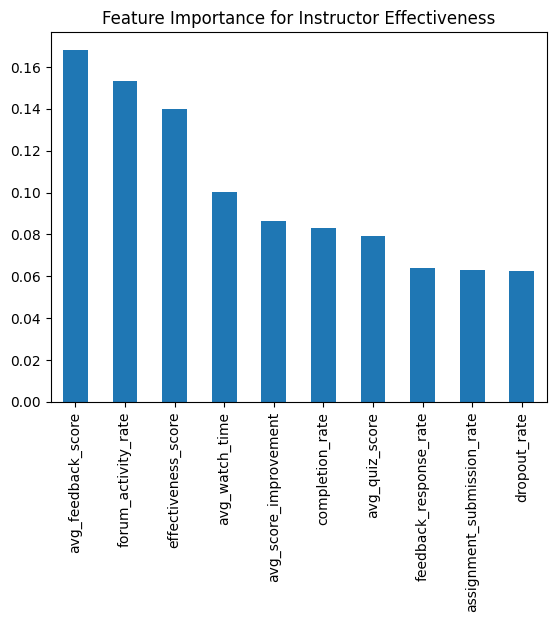

In [26]:
importance.plot(kind="bar")
plt.title("Feature Importance for Instructor Effectiveness")
plt.show()


**Which features most influenced instructor effectiveness?**

Completion rate, quiz score, and assignment submission rate
were the most influential factors. These metrics directly
reflect student engagement and learning success.

**Which variables could be misleading?**

Feedback scores may be biased since students may rate
instructors based on course difficulty rather than
teaching effectiveness.

**How could the model fail?**

The model may fail if course difficulty varies significantly
across instructors or if student backgrounds differ widely.

**What additional data would improve the analysis?**

Additional useful data could include instructor experience,
course difficulty level, student demographics, and
time spent on assignments.

**Should this model be used for instructor evaluation?**

The model should not be used as the sole evaluation method.
It should complement other measures such as peer reviews,
student feedback, and teaching observations.

# Final Conclusion

This project demonstrates how machine learning can be used
to estimate instructor effectiveness using learner outcomes,
engagement metrics, and feedback data.

Such models can help EdTech platforms identify teaching
patterns and improve course quality, while acknowledging
the limitations of purely data-driven evaluation.